# Grafics and data things


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

df = pd.read_csv("../data/processed/full_dataset.csv")
df.head()

,title,text,subject,date,target,full_text,text_length,word_count,title_length,year,month,weekday
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31,0,as u s budget fight looms republicans flip the...,4531,758,64,2017.0,12.0,6.0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29,0,u s military to accept transgender recruits on...,4029,641,64,2017.0,12.0,4.0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31,0,senior u s republican senator let mr mueller d...,2770,475,60,2017.0,12.0,6.0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30,0,fbi russia probe helped by australian diplomat...,2456,396,59,2017.0,12.0,5.0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29,0,trump wants postal service to charge much more...,5039,858,69,2017.0,12.0,4.0


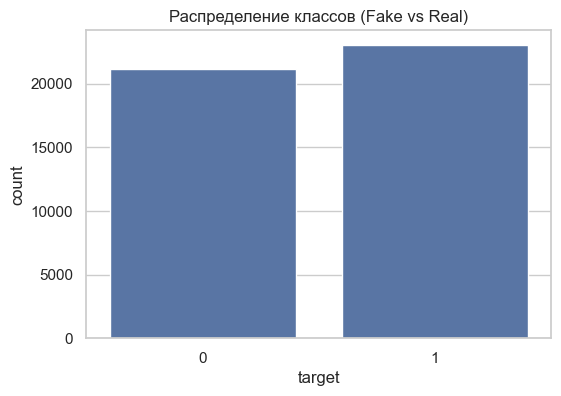

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Распределение классов (Fake vs Real)")
plt.show()

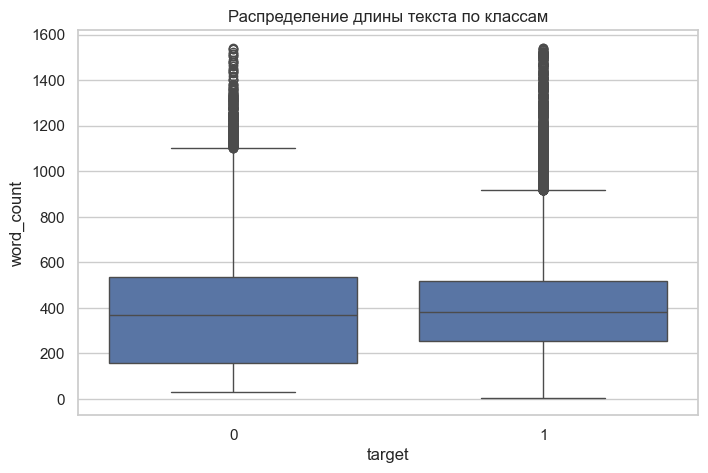

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="word_count", data=df)
plt.title("Распределение длины текста по классам")
plt.show()

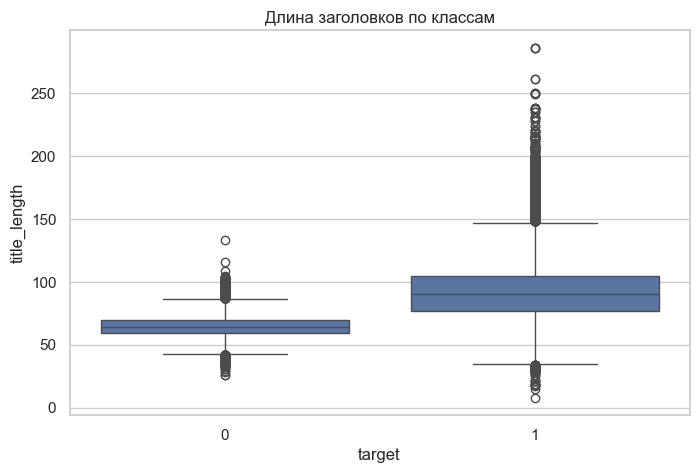

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="title_length", data=df)
plt.title("Длина заголовков по классам")
plt.show()

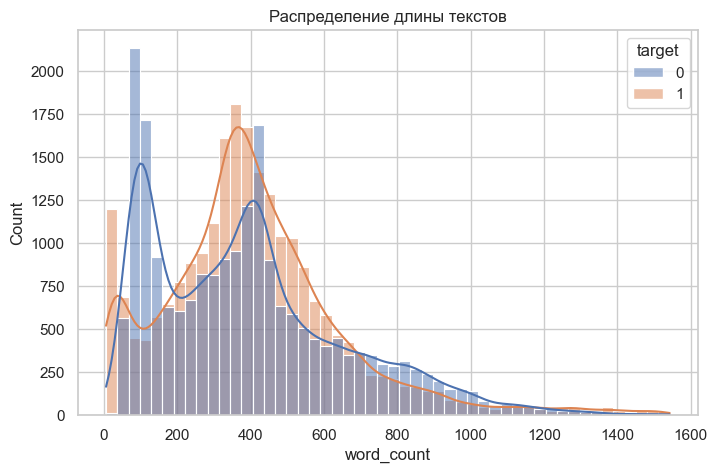

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="word_count", hue="target", bins=50, kde=True)
plt.title("Распределение длины текстов")
plt.show()

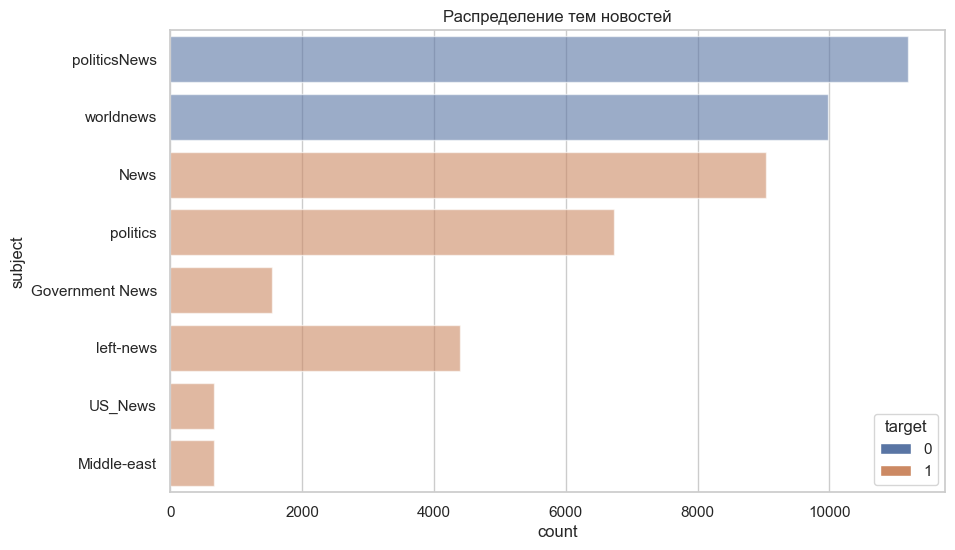

In [30]:
# темы новостей я не буду учитывать
plt.figure(figsize=(10,6))
ax = sns.countplot(y="subject", hue="target", data=df)

for patch in ax.patches:
    patch.set_alpha(0.6)

plt.title("Распределение тем новостей")
plt.show()

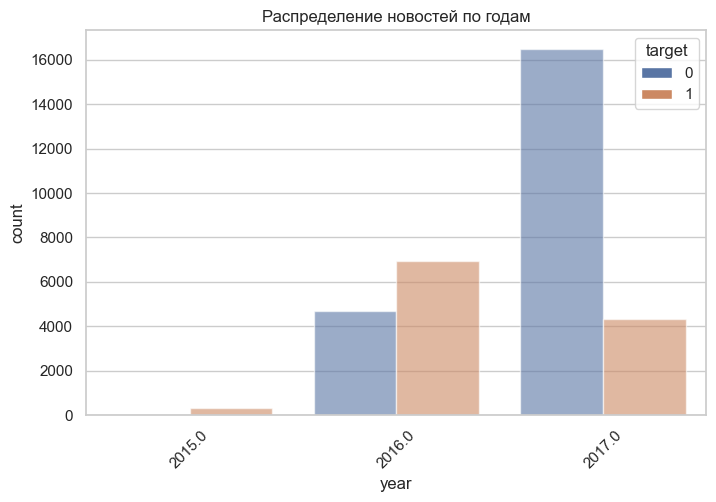

In [31]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x="year", hue="target", data=df)

for patch in ax.patches:
    patch.set_alpha(0.6)

plt.title("Распределение новостей по годам")
plt.xticks(rotation=45)
plt.show()

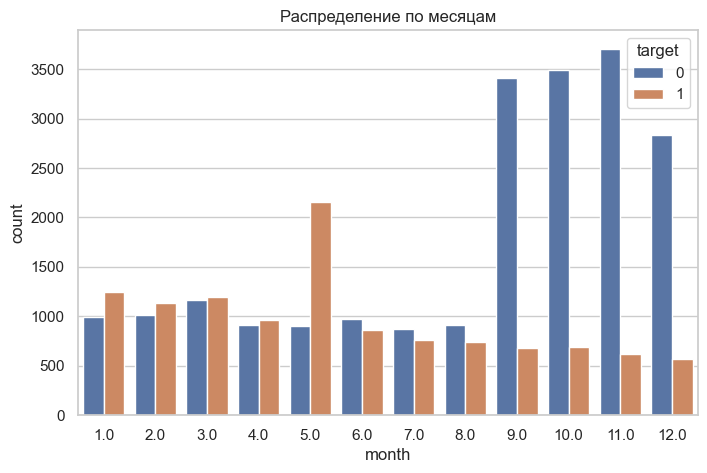

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x="month", hue="target", data=df)
plt.title("Распределение по месяцам")
plt.show()

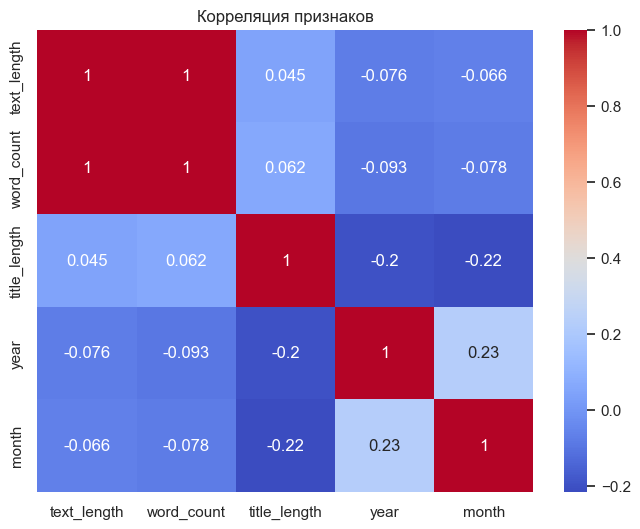

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["text_length", "word_count", "title_length", "year", "month"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Корреляция признаков")
plt.show()

In [34]:
df.groupby("target")["word_count"].mean()

target
0    395.213446
1    406.981518
Name: word_count, dtype: float64

In [35]:
print(df.groupby("target")[["word_count", "title_length"]].describe())

       word_count                                                             \
            count        mean         std   min    25%    50%    75%     max   
target                                                                         
0         21181.0  395.213446  266.440466  29.0  157.0  370.0  535.0  1541.0   
1         23050.0  406.981518  247.393280   6.0  256.0  382.0  520.0  1543.0   

       title_length                                                        
              count       mean        std   min   25%   50%    75%    max  
target                                                                     
0           21181.0  64.666069   9.152339  26.0  59.0  64.0   70.0  133.0  
1           23050.0  94.248590  27.090091   8.0  77.0  90.0  105.0  286.0  


## выводы
признаки даты и тематики частично коррелируют: subject нет смысла брать, даты распределены с явным перевесом. Чтобы избежать переобучения, я эти признаки исключу из основной модели.